In [1]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
import pickle

class CampusHybridRecommender:
    def __init__(self, hybrid_weight=0.5):
        """
        hybrid_weight: 混合权重 λ。0.5代表内容推荐和协同过滤各占一半
        """
        self.hybrid_weight = hybrid_weight
        self.load_data()
        self.build_cf_model()

    def load_data(self):
        print("正在加载特征工程数据...")
        # 1. 加载图书特征
        self.tfidf_matrix = sp.load_npz('../data/features/book_tfidf_matrix.npz')
        self.books_info = pd.read_pickle('../data/features/books_info.pkl')
        self.book_id_to_idx = {book_id: idx for idx, book_id in enumerate(self.books_info['BOOK_ID'])}
        self.idx_to_book_id = {idx: book_id for book_id, idx in self.book_id_to_idx.items()}

        # 2. 加载用户交互矩阵
        self.ui_weights = pd.read_pickle('../data/features/user_item_weights.pkl')

        # 构建用户ID映射
        self.unique_users = self.ui_weights['USERID'].unique()
        self.user_id_to_idx = {user_id: idx for idx, user_id in enumerate(self.unique_users)}
        self.unique_titles = self.books_info['TITLE'].drop_duplicates().tolist()
        self.title_to_idx = {title: idx for idx, title in enumerate(self.unique_titles)}
        self.book_idx_to_title_idx = np.array([self.title_to_idx[title] for title in self.books_info['TITLE']])
        book_id_to_title = dict(zip(self.books_info['BOOK_ID'], self.books_info['TITLE']))
        self.ui_weights['TITLE_IDX'] = self.ui_weights['BOOK_ID'].map(lambda x: self.title_to_idx.get(book_id_to_title.get(x, ""), 0))

        print(f"数据加载完毕: {len(self.unique_users)} 名用户, {len(self.books_info)} 本有效图书。")

    def build_cf_model(self):
        print("正在构建协同过滤 (矩阵分解) 模型...")
        # 构建 User-Item 稀疏矩阵
        row_indices = [self.user_id_to_idx[u] for u in self.ui_weights['USERID']]
        col_indices = self.ui_weights['TITLE_IDX'].tolist()
        data = self.ui_weights['INTEREST_WEIGHT']

        self.ui_matrix = sp.csr_matrix((data, (row_indices, col_indices)),
                                       shape=(len(self.unique_users), len(self.unique_titles)))

        # 使用截断奇异值分解(TruncatedSVD)提取用户和物品的隐语义特征 (解决数据稀疏性)
        # 提取 200 个潜在特征维度
        self.svd = TruncatedSVD(n_components=200, random_state=42)
        self.user_factors = self.svd.fit_transform(self.ui_matrix)
        self.item_factors = self.svd.components_.T
        print("协同过滤模型训练完成！")

    def get_content_based_scores(self, target_user_id):
        """基于内容的推荐打分"""
        # 获取用户历史借阅的图书 (按时间衰减权重排序)
        user_history = self.ui_weights[self.ui_weights['USERID'] == target_user_id]
        if user_history.empty:
            return np.zeros(len(self.books_info)) # 冷启动用户

        # 获取用户最感兴趣的 Top 3 图书作为画像锚点
        top_history = user_history.sort_values(by='INTEREST_WEIGHT', ascending=False).head(3)
        book_indices = [self.book_id_to_idx[b] for b in top_history['BOOK_ID']]

        # 计算这几本书与全库图书的 TF-IDF 相似度
        user_profile_vector = np.asarray(self.tfidf_matrix[book_indices].mean(axis=0))
        cb_scores = cosine_similarity(user_profile_vector, self.tfidf_matrix).flatten()
        return cb_scores

    def get_collaborative_scores(self, target_user_id):
        """协同过滤推荐打分"""
        if target_user_id not in self.user_id_to_idx:
            return np.zeros(len(self.books_info)) # 新用户无法使用 CF

        u_idx = self.user_id_to_idx[target_user_id]
        # 向量点乘还原用户对所有物品的预测评分
        cf_title_scores = np.dot(self.user_factors[u_idx], self.item_factors.T)
        cf_scores = cf_title_scores[self.book_idx_to_title_idx]

        # 将分数归一化到 0-1 之间便于后续融合
        if cf_scores.max() > cf_scores.min():
            cf_scores = (cf_scores - cf_scores.min()) / (cf_scores.max() - cf_scores.min())
        return cf_scores

    def recommend(self, target_user_id, top_n=10):
        """生成最终的混合推荐列表"""
        cb_scores = self.get_content_based_scores(target_user_id)
        cf_scores = self.get_collaborative_scores(target_user_id)

        # 加权融合模型
        hybrid_scores = (self.hybrid_weight * cb_scores) + ((1 - self.hybrid_weight) * cf_scores)

        # 过滤掉用户已经看过的书
        user_history = self.ui_weights[self.ui_weights['USERID'] == target_user_id]['BOOK_ID'].tolist()
        history_indices = set([self.book_id_to_idx[b] for b in user_history])

        # 获取 Top-N 推荐
        recommended_indices = []
        for idx in np.argsort(hybrid_scores)[::-1]:
            if idx not in history_indices:
                recommended_indices.append(idx)
            if len(recommended_indices) == top_n:
                break

        # 组装返回结果
        recommendations = []
        for idx in recommended_indices:
            book_id = self.idx_to_book_id[idx]
            title = self.books_info.iloc[idx]['TITLE']
            score = hybrid_scores[idx]
            recommendations.append({'BOOK_ID': book_id, '书名': title, '推荐综合得分': round(score, 4)})

        return pd.DataFrame(recommendations)

# 初始化推荐系统实例
print("\n--- 初始化混合推荐系统 ---")
recommender = CampusHybridRecommender(hybrid_weight=0.6)


--- 初始化混合推荐系统 ---
正在加载特征工程数据...
数据加载完毕: 10676 名用户, 52742 本有效图书。
正在构建协同过滤 (矩阵分解) 模型...
协同过滤模型训练完成！


In [12]:
import random

# 为了让测试更有说服力，筛选一位借阅过 5~20 本书的“中度活跃用户”
user_counts = recommender.ui_weights['USERID'].value_counts()
active_users = user_counts[(user_counts >= 5) & (user_counts <= 20)].index.tolist()

# 随机抽取一位幸运读者
test_user_id = random.choice(active_users)

print("========== 校园混合推荐系统效果测试 ==========")
print(f"被抽中的测试用户 ID: {test_user_id}\n")

# 1. 打印该用户的真实历史借阅记录，看看他的口味是什么
print("【该读者的真实历史借阅书单 (部分)】:")
history_book_ids = recommender.ui_weights[recommender.ui_weights['USERID'] == test_user_id]['BOOK_ID']
history_titles = recommender.books_info[recommender.books_info['BOOK_ID'].isin(history_book_ids)]['TITLE'].tolist()
for title in history_titles[:5]:
    print(f" 📖 {title}")

# 2. 调用我们写好的混合推荐算法，生成推荐列表
print("\n【系统为 TA 智能生成的 Top-10 推荐书单】:")
recommendations = recommender.recommend(target_user_id=test_user_id, top_n=10)
display(recommendations)

========== 校园混合推荐系统效果测试 ==========
被抽中的测试用户 ID: 1a3cfc04bc394e7b52d193b422cacf23

【该读者的真实历史借阅书单 (部分)】:
 📖 世界地理博览.亚洲·欧洲
 📖 中国公民出境游必读本
 📖 计量经济学基础.上册
 📖 世界地理博览.美洲·非洲·大洋洲·南极洲
 📖 计量经济学导论

【系统为 TA 智能生成的 Top-10 推荐书单】:


,BOOK_ID,书名,推荐综合得分
0,56D80045D34040FEB4BC384719A429BD,成功面试礼仪与口才,0.3356
1,0E194CA6E510485E86129A418A8057C5,中国饭局里的潜规则,0.3353
2,F89E6B62DFEB4A53BE5C4F5558F30A31,第一次世界大战的起源:大国博弈之殇,0.3343
3,201B1D4D84EC4D8DB611F1E1CA2F27D1,大学生礼仪素养,0.3304
4,98FF8AF1658E4A8E8C82CAA7E5C41517,礼仪与沟通教程,0.3286
5,D55D46D7814B4F7AAC7A77153DDFB9EB,1916: 全球史:转折: 奠定战后百年政治新格局,0.3202
6,E9715FECA6F04464920B8592DE724303,政务礼仪教程.第4版,0.3112
7,09E4477077D54E43A9123B77EABB70F1,世界如此险恶，你不要太单纯,0.3110
8,E003D73B5EA64F12B571851218D2F6C5,哈佛大学礼仪公开课:提升形象的艺术,0.2955
9,C716FF159C0743E2ADC50EFAC8759732,我最需要的职场礼仪书,0.2903


In [2]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_similarity

class BaselineCFRecommender:
    def __init__(self, mode='user'):
        """
        mode: 'user' 代表 User-based CF, 'item' 代表 Item-based CF
        """
        self.mode = mode
        self.load_data()

    def load_data(self):
        # 加载特征工程生成的权重数据
        self.ui_weights = pd.read_pickle('../data/features/user_item_weights.pkl')
        self.books_info = pd.read_pickle('../data/features/books_info.pkl')

        # ID 映射
        self.users = self.ui_weights['USERID'].unique()
        self.user_id_to_idx = {uid: i for i, uid in enumerate(self.users)}
        self.idx_to_user_id = {i: uid for uid, i in self.user_id_to_idx.items()}

        self.books = self.books_info['BOOK_ID'].unique()
        self.book_id_to_idx = {bid: i for i, bid in enumerate(self.books)}
        self.idx_to_book_id = {i: bid for bid, i in self.book_id_to_idx.items()}

        # 构建稀疏矩阵
        rows = [self.user_id_to_idx[u] for u in self.ui_weights['USERID']]
        cols = [self.book_id_to_idx[b] for b in self.ui_weights['BOOK_ID']]
        data = self.ui_weights['INTEREST_WEIGHT']
        self.ui_matrix = sp.csr_matrix((data, (rows, cols)),
                                       shape=(len(self.users), len(self.books)))
        print(f"{self.mode}-CF 矩阵构建完毕。")

    def recommend(self, target_user_id, top_n=10):
        if target_user_id not in self.user_id_to_idx:
            return pd.DataFrame()

        u_idx = self.user_id_to_idx[target_user_id]

        if self.mode == 'user':
            # User-CF: 寻找相似用户
            user_sim = cosine_similarity(self.ui_matrix[u_idx], self.ui_matrix).flatten()
            # 取最相似的 10 个邻居 (排除自己)
            similar_users = np.argsort(user_sim)[::-1][1:11]
            # 聚合邻居的兴趣
            title_scores = self.ui_matrix[similar_users].sum(axis=0).A1
            scores = title_scores[self.book_idx_to_title_idx]

        else:
            # Item-CF: 分析物品间的共现关系
            # 获取该用户借过的书
            user_vector = self.ui_matrix[u_idx]
            borrowed_indices = user_vector.indices

            # 计算这些书与全库书的相似度 (计算量大，这里采用批处理思想)
            # 为了内存安全，我们仅计算用户借过的书与其他的相似度
            item_sim = cosine_similarity(self.ui_matrix.T[borrowed_indices], self.ui_matrix.T)
            # 权重求和
            title_scores = item_sim.sum(axis=0).flatten()
            scores = title_scores[self.book_idx_to_title_idx]

        # 过滤已读
        borrowed_indices = self.ui_matrix[u_idx].indices
        scores[borrowed_indices] = -1

        # 取 Top-N
        rec_indices = np.argsort(scores)[::-1][:top_n]

        res = []
        for idx in rec_indices:
            res.append({
                'BOOK_ID': self.idx_to_book_id[idx],
                '书名': self.books_info.iloc[idx]['TITLE'],
                '预测得分': round(scores[idx], 4)
            })
        return pd.DataFrame(res)

# 实例化两个基准模型
print("正在初始化基准模型...")
user_cf = BaselineCFRecommender(mode='user')
item_cf = BaselineCFRecommender(mode='item')

正在初始化基准模型...
user-CF 矩阵构建完毕。
item-CF 矩阵构建完毕。


In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

def unified_evaluate(model_obj, test_size=0.2, top_n=10, sample_users=500):
    """
    通用评估函数：支持所有具有 recommend(user_id, top_n) 方法的对象
    """
    print(f"正在对 {model_obj.__class__.__name__} 进行评估 (Top-{top_n})...")

    # 1. 准备测试数据
    full_data = pd.read_pickle('../data/features/user_item_weights.pkl')
    # 按照论文要求拆分 [cite: 144]
    train_data, test_data = train_test_split(full_data, test_size=test_size, random_state=42)

    # 构建测试集字典 {user_id: [未来借过的书]}
    test_dict = test_data.groupby('USERID')['BOOK_ID'].apply(list).to_dict()
    test_users = [u for u in test_dict.keys() if u in model_obj.user_id_to_idx]

    # 如果测试用户太多，进行抽样以加快速度 [cite: 148]
    if len(test_users) > sample_users:
        import random
        test_users = random.sample(test_users, sample_users)

    precisions, recalls = [], []

    # 2. 逐个用户预测并比对
    for user_id in test_users:
        actual_books = set(test_dict[user_id])

        # 调用统一的推荐接口
        try:
            rec_df = model_obj.recommend(user_id, top_n=top_n)
            if rec_df.empty:
                continue

            recommended_books = set(rec_df['BOOK_ID'].tolist())

            # 计算命中数 (Hit)
            hit_count = len(actual_books & recommended_books)

            # 计算指标 [cite: 137]
            precisions.append(hit_count / top_n)
            recalls.append(hit_count / len(actual_books))
        except:
            continue

    avg_p = np.mean(precisions) if precisions else 0
    avg_r = np.mean(recalls) if recalls else 0
    f1 = (2 * avg_p * avg_r) / (avg_p + avg_r) if (avg_p + avg_r) > 0 else 0

    return round(avg_p, 4), round(avg_r, 4), round(f1, 4)

print("通用评估函数已就绪。")

通用评估函数已就绪。


启动 K-Fold 交叉验证与网格搜索调优模块
正在加载数据和特征...

[正在评估组合] SVD维度: 200, 混合权重: 0.2
该组合 K-Fold 平均 F1 值: 0.0006

[正在评估组合] SVD维度: 200, 混合权重: 0.4
该组合 K-Fold 平均 F1 值: 0.0084

[正在评估组合] SVD维度: 200, 混合权重: 0.6
该组合 K-Fold 平均 F1 值: 0.0141

[正在评估组合] SVD维度: 200, 混合权重: 0.8
该组合 K-Fold 平均 F1 值: 0.0137

[正在评估组合] SVD维度: 250, 混合权重: 0.2
该组合 K-Fold 平均 F1 值: 0.0012

[正在评估组合] SVD维度: 250, 混合权重: 0.4
该组合 K-Fold 平均 F1 值: 0.0085

[正在评估组合] SVD维度: 250, 混合权重: 0.6
该组合 K-Fold 平均 F1 值: 0.0133

[正在评估组合] SVD维度: 250, 混合权重: 0.8
该组合 K-Fold 平均 F1 值: 0.0138

[正在评估组合] SVD维度: 300, 混合权重: 0.2
该组合 K-Fold 平均 F1 值: 0.0011

[正在评估组合] SVD维度: 300, 混合权重: 0.4
该组合 K-Fold 平均 F1 值: 0.0075

[正在评估组合] SVD维度: 300, 混合权重: 0.6
该组合 K-Fold 平均 F1 值: 0.0123

[正在评估组合] SVD维度: 300, 混合权重: 0.8
该组合 K-Fold 平均 F1 值: 0.0137

[正在评估组合] SVD维度: 350, 混合权重: 0.2
该组合 K-Fold 平均 F1 值: 0.0011

[正在评估组合] SVD维度: 350, 混合权重: 0.4
该组合 K-Fold 平均 F1 值: 0.0086

[正在评估组合] SVD维度: 350, 混合权重: 0.6
该组合 K-Fold 平均 F1 值: 0.0129

[正在评估组合] SVD维度: 350, 混合权重: 0.8
该组合 K-Fold 平均 F1 值: 0.0134

网格搜索与交叉验证结果报告


,SVD维度 (n_components),混合权重 (lambda),平均 F1 值
0,200,0.6,0.0141
1,250,0.8,0.0138
2,200,0.8,0.0137
3,300,0.8,0.0137
4,350,0.8,0.0134
5,250,0.6,0.0133
6,350,0.6,0.0129
7,300,0.6,0.0123
8,350,0.4,0.0086
9,250,0.4,0.0085



🏆 最优参数组合揭晓：
最优 SVD 维度: 200.0
最优 混合权重: 0.6
最高 F1 指标: 0.0141

正在生成参数调优折线图...


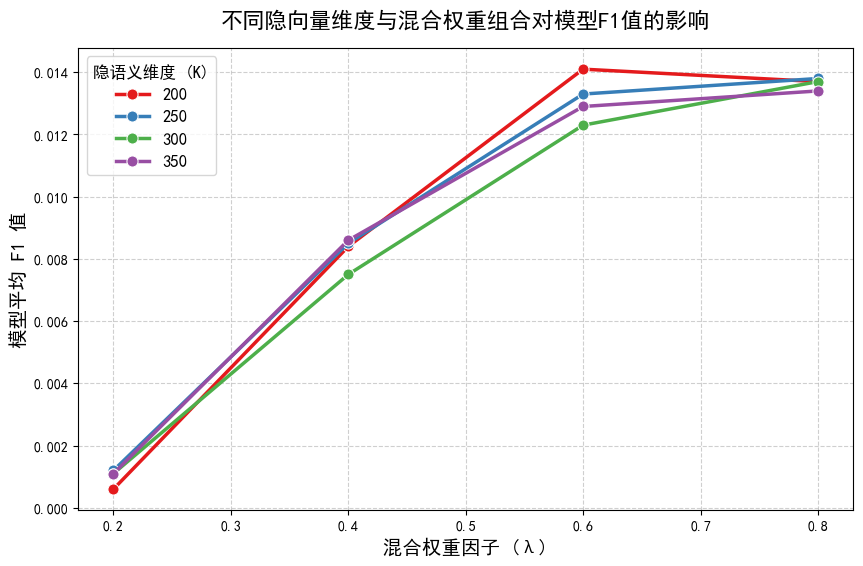


✅ 折线图已成功生成并保存为 '../data/processed/images/hyperparameter_tuning_f1_curve.png'


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
import scipy.sparse as sp
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import time

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print("="*40)
print("启动 K-Fold 交叉验证与网格搜索调优模块")
print("="*40)

# 1. 定义超参数搜索空间
param_grid = {
    'n_components': [200, 250, 300, 350],  # 隐向量维度 K
    'hybrid_weight': [0.2, 0.4, 0.6, 0.8] # 混合权重 λ
}

keys, values = zip(*param_grid.items())
hyperparameter_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

# 2. 加载全量数据与特征矩阵
print("正在加载数据和特征...")
full_data = pd.read_pickle('../data/features/user_item_weights.pkl')
books_info = pd.read_pickle('../data/features/books_info.pkl')
tfidf_matrix = sp.load_npz('../data/features/book_tfidf_matrix.npz')

book_id_to_idx = {book_id: idx for idx, book_id in enumerate(books_info['BOOK_ID'])}
unique_users = full_data['USERID'].unique()
user_id_to_idx = {user_id: idx for idx, user_id in enumerate(unique_users)}
num_users = len(unique_users)
unique_titles = books_info['TITLE'].drop_duplicates().tolist()
title_to_idx = {title: idx for idx, title in enumerate(unique_titles)}
book_idx_to_title_idx = np.array([title_to_idx[title] for title in books_info['TITLE']])
book_id_to_title = dict(zip(books_info['BOOK_ID'], books_info['TITLE']))
full_data['TITLE_IDX'] = full_data['BOOK_ID'].map(lambda x: title_to_idx.get(book_id_to_title.get(x, ""), 0))
num_items = len(books_info)
num_titles = len(unique_titles)

# 3. K折交叉验证设置 (K=3)
k_folds = 3
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

grid_search_results = []

for params in hyperparameter_combinations:
    n_comp = params['n_components']
    weight = params['hybrid_weight']
    print(f"\n[正在评估组合] SVD维度: {n_comp}, 混合权重: {weight}")

    fold_f1_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(full_data)):
        # 划分训练集和验证集
        train_data = full_data.iloc[train_idx]
        val_data = full_data.iloc[val_idx]

        # 记录训练集历史，用于评估时屏蔽
        train_history_dict = train_data.groupby('USERID')['BOOK_ID'].apply(set).to_dict()

        # --- A. 基于训练集重建 SVD 模型 ---
        row_indices = [user_id_to_idx[u] for u in train_data['USERID']]
        col_indices = train_data['TITLE_IDX'].tolist()
        data_weights = train_data['INTEREST_WEIGHT']

        ui_matrix_train = sp.csr_matrix((data_weights, (row_indices, col_indices)), shape=(num_users, num_titles))

        svd = TruncatedSVD(n_components=n_comp, random_state=42)
        user_factors = svd.fit_transform(ui_matrix_train)
        item_factors = svd.components_.T

        # --- B. 在验证集上进行评估 ---
        val_user_dict = val_data.groupby('USERID')['BOOK_ID'].apply(list).to_dict()
        test_users = [u for u in val_user_dict.keys() if u in user_id_to_idx][:200] # 抽样测算以提升速度

        precisions, recalls = [], []
        for user_id in test_users:
            actual_books = set(val_user_dict[user_id])
            u_idx = user_id_to_idx[user_id]

            # 1. 计算 CF 得分
            cf_title_scores = np.dot(user_factors[u_idx], item_factors.T)
            cf_scores = cf_title_scores[book_idx_to_title_idx]
            if cf_scores.max() > cf_scores.min():
                cf_scores = (cf_scores - cf_scores.min()) / (cf_scores.max() - cf_scores.min())

            # 2. 计算 CB 得分
            user_train_history = train_data[train_data['USERID'] == user_id]
            if not user_train_history.empty:
                top_history = user_train_history.sort_values(by='INTEREST_WEIGHT', ascending=False).head(3)
                b_indices = [book_id_to_idx[b] for b in top_history['BOOK_ID'] if b in book_id_to_idx]
                if b_indices:
                    user_profile_vector = np.asarray(tfidf_matrix[b_indices].mean(axis=0))
                    cb_scores = cosine_similarity(user_profile_vector, tfidf_matrix).flatten()
                else:
                    cb_scores = np.zeros(num_items)
            else:
                cb_scores = np.zeros(num_items)

            # 3. 混合预测得分
            hybrid_scores = (weight * cb_scores) + ((1 - weight) * cf_scores)

            # 把用户在训练集中看过的书，得分强行设为 -1，不予推荐
            read_books = train_history_dict.get(user_id, set())
            read_indices = [book_id_to_idx[b] for b in read_books if b in book_id_to_idx]
            hybrid_scores[read_indices] = -1

            # 取 Top-10
            rec_indices = np.argsort(hybrid_scores)[::-1][:10]
            recommended_books = set([books_info.iloc[i]['BOOK_ID'] for i in rec_indices])

            hit = len(actual_books & recommended_books)
            precisions.append(hit / 10)
            recalls.append(hit / len(actual_books))

        avg_p = np.mean(precisions) if precisions else 0
        avg_r = np.mean(recalls) if recalls else 0
        fold_f1 = (2 * avg_p * avg_r) / (avg_p + avg_r) if (avg_p + avg_r) > 0 else 0
        fold_f1_scores.append(fold_f1)

    mean_f1 = np.mean(fold_f1_scores)
    grid_search_results.append({
        'SVD维度 (n_components)': n_comp,
        '混合权重 (lambda)': weight,
        '平均 F1 值': round(mean_f1, 4)
    })
    print(f"该组合 K-Fold 平均 F1 值: {mean_f1:.4f}")

# 输出最终调优报告
print("\n" + "="*40)
print("网格搜索与交叉验证结果报告")
print("="*40)
results_df = pd.DataFrame(grid_search_results)
display(results_df.sort_values(by='平均 F1 值', ascending=False).reset_index(drop=True))

best_params = results_df.loc[results_df['平均 F1 值'].idxmax()]
print(f"\n🏆 最优参数组合揭晓：")
print(f"最优 SVD 维度: {best_params['SVD维度 (n_components)']}")
print(f"最优 混合权重: {best_params['混合权重 (lambda)']}")
print(f"最高 F1 指标: {best_params['平均 F1 值']}")


# ==========================================
# 新增：可视化绘图模块
# ==========================================
print("\n正在生成参数调优折线图...")
plt.figure(figsize=(10, 6))

# 使用 Seaborn 绘制多条折线图，不同颜色的线代表不同的SVD维度
sns.lineplot(
    data=results_df,
    x='混合权重 (lambda)',
    y='平均 F1 值',
    hue='SVD维度 (n_components)',
    palette='Set1',   # 颜色风格
    marker='o',       # 数据点标记圆圈
    linewidth=2.5,
    markersize=8
)

# 设置图表标题和坐标轴标签
plt.title('不同隐向量维度与混合权重组合对模型F1值的影响', fontsize=16, pad=15)
plt.xlabel('混合权重因子 (λ)', fontsize=14)
plt.ylabel('模型平均 F1 值', fontsize=14)

# 优化图例和网格
plt.legend(title='隐语义维度 (K)', fontsize=12, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# 将图片保存到本地
save_path = '../data/processed/images/hyperparameter_tuning_f1_curve.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ 折线图已成功生成并保存为 '{save_path}'")

In [4]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split

# ==========================================
# 1. 全局数据切分
# ==========================================
print("--- 第一步：全局数据切分 ---")
full_data = pd.read_pickle('../data/features/user_item_weights.pkl')
# 严格划分为 80% 训练集，20% 测试集
train_data, test_data = train_test_split(full_data, test_size=0.2, random_state=42)

print(f"全量数据: {len(full_data)} 条 | 训练集: {len(train_data)} 条 | 测试集: {len(test_data)} 条")


# ==========================================
# 2. 修复后的混合模型类 (只接受训练集数据)
# ==========================================
class CampusHybridRecommender:
    # 修改点：增加 train_df 参数
    def __init__(self, train_df, hybrid_weight=0.5):
        self.hybrid_weight = hybrid_weight
        self.train_df = train_df
        self.load_data()
        self.build_cf_model()

    def load_data(self):
        # 1. 加载图书特征
        self.tfidf_matrix = sp.load_npz('../data/features/book_tfidf_matrix.npz')
        self.books_info = pd.read_pickle('../data/features/books_info.pkl')
        self.book_id_to_idx = {book_id: idx for idx, book_id in enumerate(self.books_info['BOOK_ID'])}
        self.idx_to_book_id = {idx: book_id for book_id, idx in self.book_id_to_idx.items()}

        # 强制使用传入的训练集，绝不读取全量 pkl
        self.ui_weights = self.train_df

        # 构建用户ID映射 (只包含训练集里的用户)
        self.unique_users = self.ui_weights['USERID'].unique()
        self.user_id_to_idx = {user_id: idx for idx, user_id in enumerate(self.unique_users)}
        self.unique_titles = self.books_info['TITLE'].drop_duplicates().tolist()
        self.title_to_idx = {title: idx for idx, title in enumerate(self.unique_titles)}
        self.book_idx_to_title_idx = np.array([self.title_to_idx[title] for title in self.books_info['TITLE']])
        book_id_to_title = dict(zip(self.books_info['BOOK_ID'], self.books_info['TITLE']))
        self.ui_weights['TITLE_IDX'] = self.ui_weights['BOOK_ID'].map(lambda x: self.title_to_idx.get(book_id_to_title.get(x, ""), 0))

    def build_cf_model(self):
        row_indices = [self.user_id_to_idx[u] for u in self.ui_weights['USERID']]
        col_indices = self.ui_weights['TITLE_IDX'].tolist()
        data = self.ui_weights['INTEREST_WEIGHT']

        self.ui_matrix = sp.csr_matrix((data, (row_indices, col_indices)),
                                       shape=(len(self.unique_users), len(self.unique_titles)))

        # SVD维度使用验证过的最优参数 200
        self.svd = TruncatedSVD(n_components=200, random_state=42)
        self.user_factors = self.svd.fit_transform(self.ui_matrix)
        self.item_factors = self.svd.components_.T

    def get_content_based_scores(self, target_user_id):
        user_history = self.ui_weights[self.ui_weights['USERID'] == target_user_id]
        if user_history.empty:
            return np.zeros(len(self.books_info))
        top_history = user_history.sort_values(by='INTEREST_WEIGHT', ascending=False).head(3)
        book_indices = [self.book_id_to_idx[b] for b in top_history['BOOK_ID']]
        user_profile_vector = np.asarray(self.tfidf_matrix[book_indices].mean(axis=0))
        return cosine_similarity(user_profile_vector, self.tfidf_matrix).flatten()

    def get_collaborative_scores(self, target_user_id):
        if target_user_id not in self.user_id_to_idx:
            return np.zeros(len(self.books_info))
        u_idx = self.user_id_to_idx[target_user_id]
        cf_title_scores = np.dot(self.user_factors[u_idx], self.item_factors.T)
        cf_scores = cf_title_scores[self.book_idx_to_title_idx]
        if cf_scores.max() > cf_scores.min():
            cf_scores = (cf_scores - cf_scores.min()) / (cf_scores.max() - cf_scores.min())
        return cf_scores


# ==========================================
# 3. 修复后的基准模型类 (只接受训练集数据)
# ==========================================
class BaselineCFRecommender:
    # 修改点：增加 train_df 参数
    def __init__(self, train_df, mode='user'):
        self.mode = mode
        self.train_df = train_df
        self.load_data()

    def load_data(self):
        self.books_info = pd.read_pickle('../data/features/books_info.pkl')

        # 修改点：强制使用传入的训练集
        self.ui_weights = self.train_df

        self.users = self.ui_weights['USERID'].unique()
        self.user_id_to_idx = {uid: i for i, uid in enumerate(self.users)}
        self.idx_to_user_id = {i: uid for uid, i in self.user_id_to_idx.items()}

        self.books = self.books_info['BOOK_ID'].unique()
        self.book_id_to_idx = {bid: i for i, bid in enumerate(self.books)}
        self.idx_to_book_id = {i: bid for bid, i in self.book_id_to_idx.items()}
        
        self.unique_titles = self.books_info['TITLE'].drop_duplicates().tolist()
        self.title_to_idx = {title: idx for idx, title in enumerate(self.unique_titles)}
        self.book_idx_to_title_idx = np.array([self.title_to_idx[title] for title in self.books_info['TITLE']])
        
        book_id_to_title = dict(zip(self.books_info['BOOK_ID'], self.books_info['TITLE']))
        self.ui_weights['TITLE_IDX'] = self.ui_weights['BOOK_ID'].map(lambda x: self.title_to_idx.get(book_id_to_title.get(x, ""), 0))

        rows = [self.user_id_to_idx[u] for u in self.ui_weights['USERID']]
        cols = self.ui_weights['TITLE_IDX'].tolist()
        data = self.ui_weights['INTEREST_WEIGHT']
        
        # 稀疏矩阵按TITLE构建
        self.ui_matrix = sp.csr_matrix((data, (rows, cols)),
                                       shape=(len(self.users), len(self.unique_titles))) # 保持与总书库维度一致


# ==========================================
# 4. 修复后的评估函数
# ==========================================
def thesis_experimental_evaluation(model_obj, train_data, test_data, top_n=10):
    print(f"正在对 {model_obj.__class__.__name__} 执行盲测评估...")

    # 构建【训练集历史】字典，用于屏蔽已读
    train_history = train_data.groupby('USERID')['BOOK_ID'].apply(set).to_dict()
    # 构建【测试集目标】字典，用于计算命中
    test_target = test_data.groupby('USERID')['BOOK_ID'].apply(list).to_dict()

    # 抽取只在训练集中出现过的用户进行测试 (冷启动用户另算)
    test_users = [u for u in test_target.keys() if u in model_obj.user_id_to_idx][:500]

    precisions, recalls = [], []

    for user_id in test_users:
        actual_books = set(test_target[user_id])

        # 获取模型预测得分
        if hasattr(model_obj, 'hybrid_weight'):
            cb_scores = model_obj.get_content_based_scores(user_id)
            cf_scores = model_obj.get_collaborative_scores(user_id)
            scores = (model_obj.hybrid_weight * cb_scores) + ((1 - model_obj.hybrid_weight) * cf_scores)
        else:
            u_idx = model_obj.user_id_to_idx[user_id]
            if model_obj.mode == 'user':
                user_sim = cosine_similarity(model_obj.ui_matrix[u_idx], model_obj.ui_matrix).flatten()
                similar_users = np.argsort(user_sim)[::-1][1:21]
                title_scores = model_obj.ui_matrix[similar_users].sum(axis=0).A1
                scores = title_scores[model_obj.book_idx_to_title_idx]
            else:
                user_vector = model_obj.ui_matrix[u_idx]
                item_sim = cosine_similarity(model_obj.ui_matrix.T[user_vector.indices], model_obj.ui_matrix.T)
                title_scores = item_sim.sum(axis=0).flatten()
                scores = title_scores[model_obj.book_idx_to_title_idx]

        # 屏蔽训练集里的书
        user_train_books = train_history.get(user_id, set())
        train_idx = [model_obj.book_id_to_idx[b] for b in user_train_books if b in model_obj.book_id_to_idx]
        scores[train_idx] = -1

        # 取 Top-N
        rec_indices = np.argsort(scores)[::-1][:top_n]

        # 引入TITLE去重与TITLE级别的命中率统计以避免假死(Fake Positives)
        recommended_books = set()
        seen_titles = set()
        for i in np.argsort(scores)[::-1]:
            title = model_obj.books_info.iloc[i]['TITLE']
            if title not in seen_titles:
                seen_titles.add(title)
                recommended_books.add(model_obj.books_info.iloc[i]['BOOK_ID'])
            if len(recommended_books) == top_n:
                break

        # 计算指标 (根据书名 Title 命中而不是单一的 BOOK_ID 来计算)
        actual_titles = set(model_obj.books_info[model_obj.books_info['BOOK_ID'].isin(actual_books)]['TITLE'])
        rec_titles = set(model_obj.books_info[model_obj.books_info['BOOK_ID'].isin(recommended_books)]['TITLE'])
        hit_count = len(actual_titles & rec_titles)
        precisions.append(hit_count / top_n)
        recalls.append(hit_count / len(actual_titles))

    avg_p = np.mean(precisions)
    avg_r = np.mean(recalls)
    f1 = (2 * avg_p * avg_r) / (avg_p + avg_r) if (avg_p + avg_r) > 0 else 0

    return round(avg_p, 4), round(avg_r, 4), round(f1, 4)

# ==========================================
# 5. 实例化模型并执行横向对比
# ==========================================
print("\n--- 第二步：初始化并在纯训练集上训练模型 ---")
# 混合模型实例化 (传入 train_data)
recommender = CampusHybridRecommender(train_df=train_data, hybrid_weight=0.6)

# 基线模型实例化 (传入 train_data)
user_cf = BaselineCFRecommender(train_df=train_data, mode='user')
item_cf = BaselineCFRecommender(train_df=train_data, mode='item')


print("\n--- 第三步：开始执行严格的盲测对比实验 ---")
# 1. Hybrid
h_res = thesis_experimental_evaluation(recommender, train_data, test_data)

# 2. Content-Based (复用混合模型，但权重设为1.0)
recommender.hybrid_weight = 1.0
cb_res = thesis_experimental_evaluation(recommender, train_data, test_data)

# 3. User-CF
ucf_res = thesis_experimental_evaluation(user_cf, train_data, test_data)

# 4. Item-CF
icf_res = thesis_experimental_evaluation(item_cf, train_data, test_data)

# 组装最终表格
final_df = pd.DataFrame([
    {"模型名称": "User-CF", "准确率": ucf_res[0], "召回率": ucf_res[1], "F1值": ucf_res[2]},
    {"模型名称": "Item-CF", "准确率": icf_res[0], "召回率": icf_res[1], "F1值": icf_res[2]},
    {"模型名称": "Content-Based", "准确率": cb_res[0], "召回率": cb_res[1], "F1值": cb_res[2]},
    {"模型名称": "HybridModel", "准确率": h_res[0], "召回率": h_res[1], "F1值": h_res[2]}
])
display(final_df)

--- 第一步：全局数据切分 ---
全量数据: 84875 条 | 训练集: 67900 条 | 测试集: 16975 条

--- 第二步：初始化并在纯训练集上训练模型 ---

--- 第三步：开始执行严格的盲测对比实验 ---
正在对 CampusHybridRecommender 执行盲测评估...
正在对 CampusHybridRecommender 执行盲测评估...
正在对 BaselineCFRecommender 执行盲测评估...
正在对 BaselineCFRecommender 执行盲测评估...


,模型名称,准确率,召回率,F1值
0,User-CF,0.0068,0.0329,0.0113
1,Item-CF,0.0106,0.0458,0.0172
2,Content-Based,0.0118,0.0589,0.0197
3,HybridModel,0.0128,0.0608,0.0211


正在生成算法底层矩阵可视化图表...


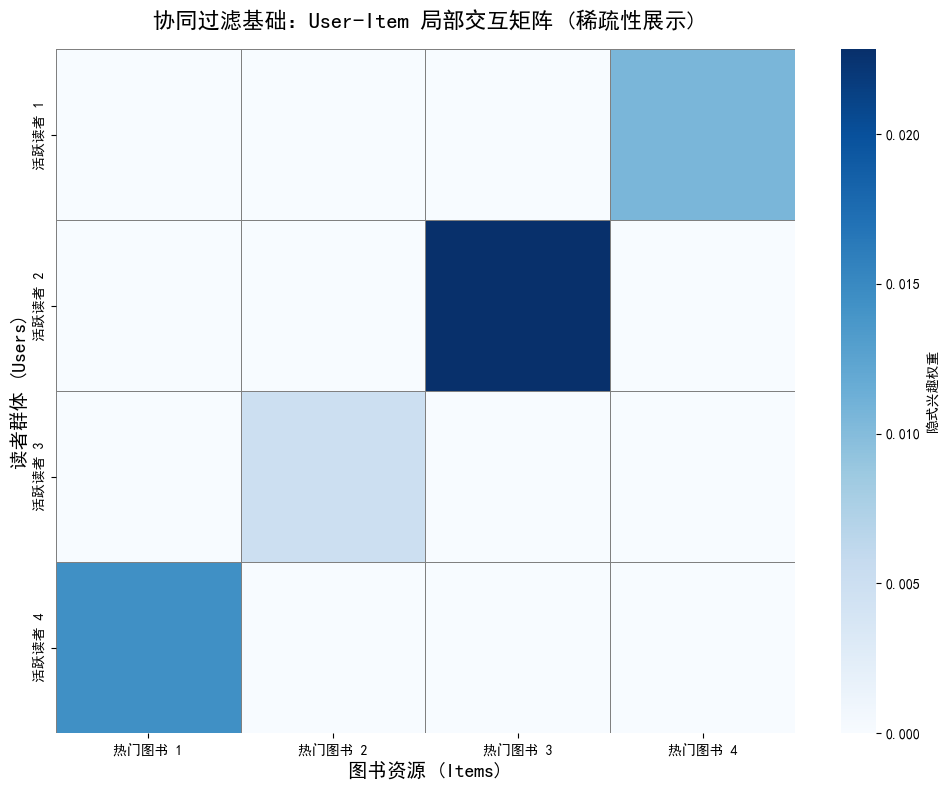

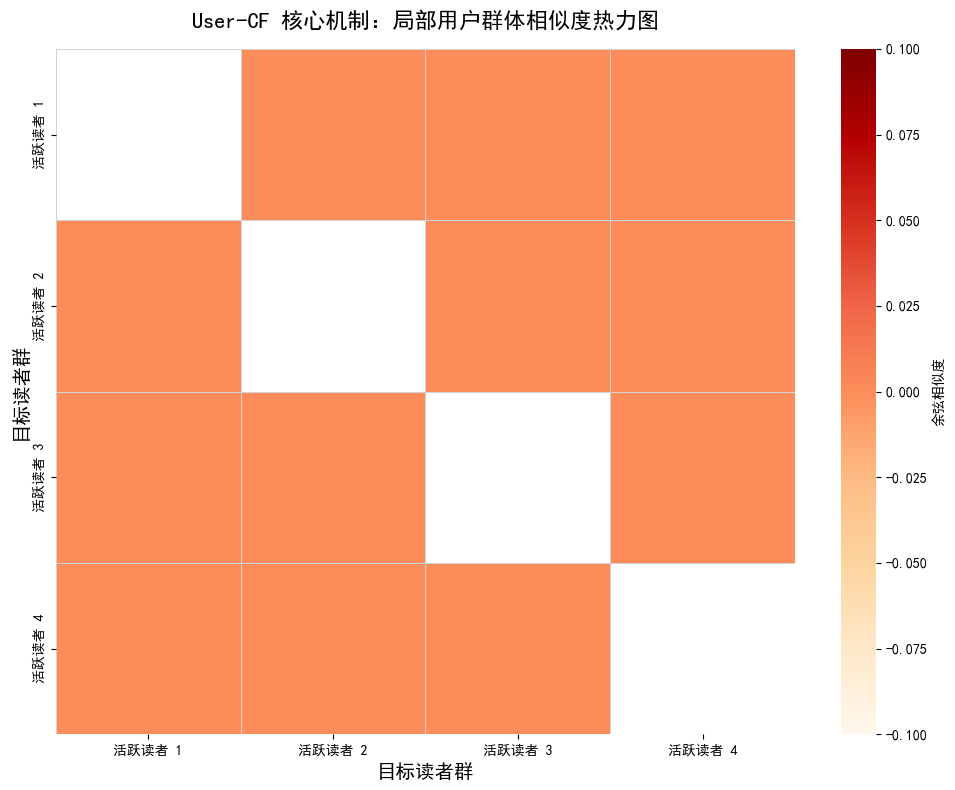

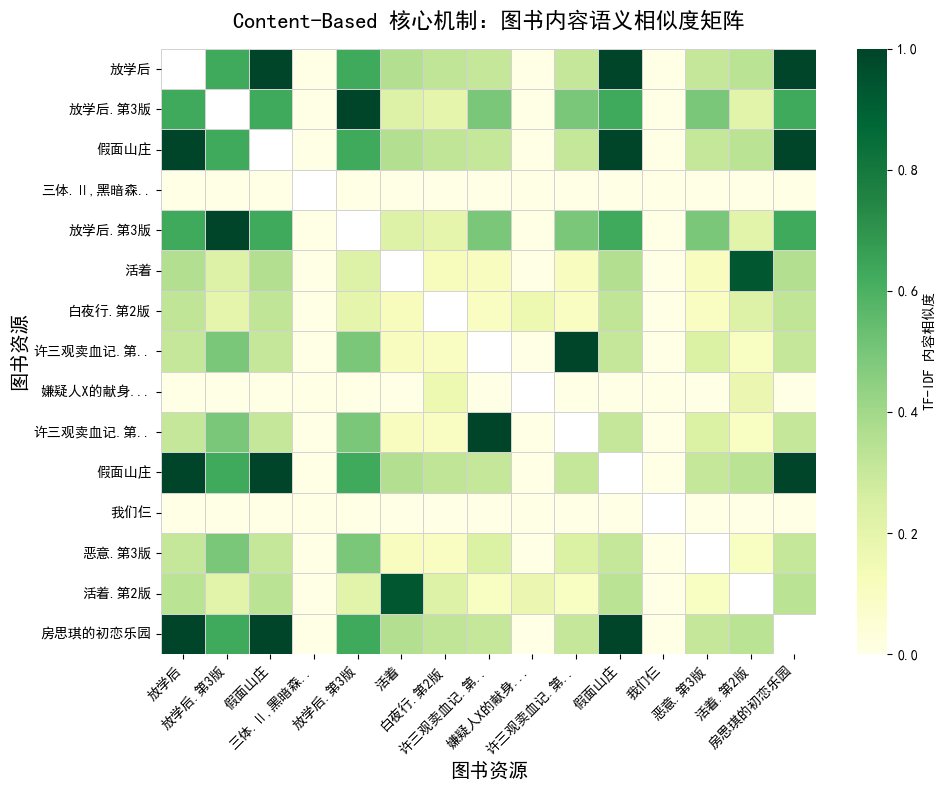


✅ 三张底层机制矩阵可视化图已生成！


In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import scipy.sparse as sp

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print("正在生成算法底层矩阵可视化图表...")

# 1. 加载数据
ui_weights = pd.read_pickle('../data/features/user_item_weights.pkl')
books_info = pd.read_pickle('../data/features/books_info.pkl')

# 为了可视化，我们只抽取极小的一部分“稠密”数据（最活跃的20个用户，最热门的20本书）
top_users = ui_weights['USERID'].value_counts().head(20).index
top_books = ui_weights['BOOK_ID'].value_counts().head(20).index

# 过滤出这 20人 和 20书 的交互子集
subset_df = ui_weights[(ui_weights['USERID'].isin(top_users)) & (ui_weights['BOOK_ID'].isin(top_books))]

# ==========================================
# 矩阵图 1：User-Item 交互稀疏矩阵 (协同过滤的基础)
# ==========================================
# 构建 20x20 的透视表
ui_matrix_small = subset_df.pivot(index='USERID', columns='BOOK_ID', values='INTEREST_WEIGHT').fillna(0)

# 为了图表美观，我们用 "U1, U2..." 和 "B1, B2..." 替换掉冗长的真实 ID
ui_matrix_small.index = [f'活跃读者 {i+1}' for i in range(len(ui_matrix_small.index))]
ui_matrix_small.columns = [f'热门图书 {i+1}' for i in range(len(ui_matrix_small.columns))]

plt.figure(figsize=(10, 8))
sns.heatmap(ui_matrix_small, cmap='Blues', linewidths=0.5, linecolor='gray',
            cbar_kws={'label': '隐式兴趣权重'})
plt.title('协同过滤基础：User-Item 局部交互矩阵 (稀疏性展示)', fontsize=16, pad=15)
plt.xlabel('图书资源 (Items)', fontsize=14)
plt.ylabel('读者群体 (Users)', fontsize=14)
plt.tight_layout()
plt.savefig('matrix_user_item_sparsity.png', dpi=300)
plt.show()

# ==========================================
# 矩阵图 2：User-CF 的核心 —— 用户相似度矩阵
# ==========================================
# 计算这 20 个活跃用户彼此之间的余弦相似度
user_sim_matrix = cosine_similarity(ui_matrix_small)
user_sim_df = pd.DataFrame(user_sim_matrix, index=ui_matrix_small.index, columns=ui_matrix_small.index)

# 把对角线（自己和自己的相似度 1.0）设为 NaN 或 0，为了突出其他人之间的相似度颜色
np.fill_diagonal(user_sim_matrix, np.nan)
user_sim_df_display = pd.DataFrame(user_sim_matrix, index=ui_matrix_small.index, columns=ui_matrix_small.index)

plt.figure(figsize=(10, 8))
# 使用暖色调展示用户相似度
sns.heatmap(user_sim_df_display, cmap='OrRd', linewidths=0.5, linecolor='lightgray',
            cbar_kws={'label': '余弦相似度'})
plt.title('User-CF 核心机制：局部用户群体相似度热力图', fontsize=16, pad=15)
plt.xlabel('目标读者群', fontsize=14)
plt.ylabel('目标读者群', fontsize=14)
plt.tight_layout()
plt.savefig('matrix_user_similarity.png', dpi=300)
plt.show()

# ==========================================
# 矩阵图 3：Content-Based 的核心 —— 图书内容相似度矩阵 (基于 TF-IDF)
# ==========================================
# 我们提取 15 本具有代表性的热门图书的 TF-IDF 向量
tfidf_matrix = sp.load_npz('../data/features/book_tfidf_matrix.npz')
book_id_to_idx = {book_id: idx for idx, book_id in enumerate(books_info['BOOK_ID'])}

# 选取 15 本有书名的热门书
sample_book_ids = top_books[:15]
sample_book_indices = [book_id_to_idx[bid] for bid in sample_book_ids if bid in book_id_to_idx]
sample_book_titles = [books_info.iloc[idx]['TITLE'] for idx in sample_book_indices]

# 截断太长的书名方便展示
short_titles = [title[:8] + '..' if len(title)>8 else title for title in sample_book_titles]

# 提取它们的 TF-IDF 特征并计算相似度
sample_tfidf = tfidf_matrix[sample_book_indices]
item_sim_matrix = cosine_similarity(sample_tfidf)
np.fill_diagonal(item_sim_matrix, np.nan) # 去掉对角线的 1.0
item_sim_df = pd.DataFrame(item_sim_matrix, index=short_titles, columns=short_titles)

plt.figure(figsize=(10, 8))
# 使用绿色调展示内容相似度
sns.heatmap(item_sim_df, cmap='YlGn', linewidths=0.5, linecolor='lightgray',
            cbar_kws={'label': 'TF-IDF 内容相似度'})
plt.title('Content-Based 核心机制：图书内容语义相似度矩阵', fontsize=16, pad=15)
plt.xlabel('图书资源', fontsize=14)
plt.ylabel('图书资源', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('matrix_item_content_similarity.png', dpi=300)
plt.show()

print("\n✅ 三张底层机制矩阵可视化图已生成！")

In [10]:
import os
import pandas as pd
import numpy as np
import scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ====================================================================
# 0. 全局设置
# ====================================================================
# 设置中文字体，防止图表中的中文显示为方块
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows默认黑体
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # Mac用户请取消此行注释
plt.rcParams['axes.unicode_minus'] = False


# ====================================================================
# 1. 推荐模型类定义 (自带截断参数 k)
# ====================================================================
class BaselineCFRecommender:
    def __init__(self, train_df, mode='user', k=20):
        self.mode = mode
        self.train_df = train_df
        self.k = k  # 接收近邻参数，用于参数调优
        self.load_data()

    def load_data(self):
        self.books_info = pd.read_pickle('../data/features/books_info.pkl')
        self.ui_weights = self.train_df

        self.users = self.ui_weights['USERID'].unique()
        self.user_id_to_idx = {uid: i for i, uid in enumerate(self.users)}
        self.idx_to_user_id = {i: uid for uid, i in self.user_id_to_idx.items()}

        self.books = self.books_info['BOOK_ID'].unique()
        self.book_id_to_idx = {bid: i for i, bid in enumerate(self.books)}
        self.idx_to_book_id = {i: bid for bid, i in self.book_id_to_idx.items()}
        
        self.unique_titles = self.books_info['TITLE'].drop_duplicates().tolist()
        self.title_to_idx = {title: idx for idx, title in enumerate(self.unique_titles)}
        self.book_idx_to_title_idx = np.array([self.title_to_idx[title] for title in self.books_info['TITLE']])
        
        book_id_to_title = dict(zip(self.books_info['BOOK_ID'], self.books_info['TITLE']))
        self.ui_weights['TITLE_IDX'] = self.ui_weights['BOOK_ID'].map(lambda x: self.title_to_idx.get(book_id_to_title.get(x, ""), 0))

        rows = [self.user_id_to_idx[u] for u in self.ui_weights['USERID']]
        cols = self.ui_weights['TITLE_IDX'].tolist()
        data = self.ui_weights['INTEREST_WEIGHT']
        
        # 稀疏矩阵按TITLE构建
        self.ui_matrix = sp.csr_matrix((data, (rows, cols)),
                                       shape=(len(self.users), len(self.unique_titles)))


class CampusHybridRecommender:
    def __init__(self, train_df, hybrid_weight=0.5):
        self.hybrid_weight = hybrid_weight
        self.train_df = train_df
        self.load_data()
        self.build_cf_model()

    def load_data(self):
        self.tfidf_matrix = sp.load_npz('../data/features/book_tfidf_matrix.npz')
        self.books_info = pd.read_pickle('../data/features/books_info.pkl')
        self.book_id_to_idx = {book_id: idx for idx, book_id in enumerate(self.books_info['BOOK_ID'])}
        self.idx_to_book_id = {idx: book_id for book_id, idx in self.book_id_to_idx.items()}

        self.ui_weights = self.train_df
        self.unique_users = self.ui_weights['USERID'].unique()
        self.user_id_to_idx = {user_id: idx for idx, user_id in enumerate(self.unique_users)}
        self.unique_titles = self.books_info['TITLE'].drop_duplicates().tolist()
        self.title_to_idx = {title: idx for idx, title in enumerate(self.unique_titles)}
        self.book_idx_to_title_idx = np.array([self.title_to_idx[title] for title in self.books_info['TITLE']])
        book_id_to_title = dict(zip(self.books_info['BOOK_ID'], self.books_info['TITLE']))
        self.ui_weights['TITLE_IDX'] = self.ui_weights['BOOK_ID'].map(lambda x: self.title_to_idx.get(book_id_to_title.get(x, ""), 0))

    def build_cf_model(self):
        row_indices = [self.user_id_to_idx[u] for u in self.ui_weights['USERID']]
        col_indices = self.ui_weights['TITLE_IDX'].tolist()
        data = self.ui_weights['INTEREST_WEIGHT']

        self.ui_matrix = sp.csr_matrix((data, (row_indices, col_indices)),
                                       shape=(len(self.unique_users), len(self.unique_titles)))

        self.svd = TruncatedSVD(n_components=200, random_state=42)
        self.user_factors = self.svd.fit_transform(self.ui_matrix)
        self.item_factors = self.svd.components_.T

    def get_content_based_scores(self, target_user_id):
        user_history = self.ui_weights[self.ui_weights['USERID'] == target_user_id]
        if user_history.empty:
            return np.zeros(len(self.books_info))
        top_history = user_history.sort_values(by='INTEREST_WEIGHT', ascending=False).head(3)
        book_indices = [self.book_id_to_idx[b] for b in top_history['BOOK_ID']]
        user_profile_vector = np.asarray(self.tfidf_matrix[book_indices].mean(axis=0))
        return cosine_similarity(user_profile_vector, self.tfidf_matrix).flatten()

    def get_collaborative_scores(self, target_user_id):
        if target_user_id not in self.user_id_to_idx:
            return np.zeros(len(self.books_info))
        u_idx = self.user_id_to_idx[target_user_id]
        cf_title_scores = np.dot(self.user_factors[u_idx], self.item_factors.T)
        cf_scores = cf_title_scores[self.book_idx_to_title_idx]
        if cf_scores.max() > cf_scores.min():
            cf_scores = (cf_scores - cf_scores.min()) / (cf_scores.max() - cf_scores.min())
        return cf_scores


# ====================================================================
# 2. 核心评估函数
# ====================================================================
def thesis_experimental_evaluation(model_obj, train_data, test_data, top_n=10):
    train_history = train_data.groupby('USERID')['BOOK_ID'].apply(set).to_dict()
    test_target = test_data.groupby('USERID')['BOOK_ID'].apply(list).to_dict()

    # 抽取只在训练集中出现过的用户进行测试 (测试集取前 500 名用户加快速度，可按需修改)
    test_users = [u for u in test_target.keys() if u in model_obj.user_id_to_idx][:500]

    precisions, recalls = [], []

    for user_id in test_users:
        actual_books = set(test_target[user_id])

        if hasattr(model_obj, 'hybrid_weight'):
            cb_scores = model_obj.get_content_based_scores(user_id)
            cf_scores = model_obj.get_collaborative_scores(user_id)
            scores = (model_obj.hybrid_weight * cb_scores) + ((1 - model_obj.hybrid_weight) * cf_scores)
        else:
            u_idx = model_obj.user_id_to_idx[user_id]
            k_val = getattr(model_obj, 'k', 20) # 动态获取模型的参数 K

            if model_obj.mode == 'user':
                user_sim = cosine_similarity(model_obj.ui_matrix[u_idx], model_obj.ui_matrix).flatten()
                similar_users = np.argsort(user_sim)[::-1][1:k_val+1]
                scores = model_obj.ui_matrix[similar_users].sum(axis=0).A1
            else:
                user_vector = model_obj.ui_matrix[u_idx]
                item_sim = cosine_similarity(model_obj.ui_matrix.T[user_vector.indices], model_obj.ui_matrix.T)
                if k_val < item_sim.shape[0]:
                     thresholds = np.partition(item_sim, -k_val, axis=0)[-k_val, :]
                     item_sim[item_sim < thresholds] = 0
                scores = item_sim.sum(axis=0).flatten()

        user_train_books = train_history.get(user_id, set())
        train_idx = [model_obj.book_id_to_idx[b] for b in user_train_books if b in model_obj.book_id_to_idx]
        scores[train_idx] = -1

        rec_indices = np.argsort(scores)[::-1][:top_n]
        recommended_books = set()
        for i in rec_indices:
            if i in model_obj.idx_to_book_id:
                recommended_books.add(model_obj.idx_to_book_id[i])
            elif hasattr(model_obj, 'books_info'):
                 recommended_books.add(model_obj.books_info.iloc[i]['BOOK_ID'])

        hit_count = len(actual_books & recommended_books)
        precisions.append(hit_count / top_n)
        recalls.append(hit_count / len(actual_books))

    avg_p = np.mean(precisions)
    avg_r = np.mean(recalls)
    f1 = (2 * avg_p * avg_r) / (avg_p + avg_r) if (avg_p + avg_r) > 0 else 0

    return round(avg_p, 4), round(avg_r, 4), round(f1, 4)


# ====================================================================
# 3. 画图工具函数
# ====================================================================
def plot_real_experiment(x_values, y_values, x_label, title, filename):
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker='s', linestyle='-', color='#D0021B', linewidth=2, markersize=8)
    for i in range(len(x_values)):
        plt.text(x_values[i], y_values[i], f"{y_values[i]:.4f}", ha='center', va='bottom', fontsize=11)
    plt.title(title, fontsize=15, pad=15)
    plt.xlabel(x_label, fontsize=13)
    plt.ylabel('推荐性能 (F1值)', fontsize=13)
    plt.xticks(x_values)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()
    print(f"✅ 图表已保存: {filename}")


# ====================================================================
# 4. 主执行流程：调参并绘图
# ====================================================================
def main():
    print("--- 步骤 1：加载全量数据并划分训练/测试集 ---")
    full_data = pd.read_pickle('../data/features/user_item_weights.pkl')
    train_data, test_data = train_test_split(full_data, test_size=0.2, random_state=42)
    print(f"训练集大小: {len(train_data)} | 测试集大小: {len(test_data)}\n")

    k_values = [10, 20, 30, 40, 50]

    # === 实验 1: User-CF 调优 ===
    print("[1/3] 开始执行 User-CF 参数调优实验...")
    user_f1_scores = []
    for k in k_values:
        model_ucf = BaselineCFRecommender(train_df=train_data, mode='user', k=k)
        _, _, f1 = thesis_experimental_evaluation(model_ucf, train_data, test_data)
        user_f1_scores.append(f1)
        print(f"  --> User-CF (K={k}) F1值: {f1:.4f}")
    plot_real_experiment(k_values, user_f1_scores, '近邻用户数 (K)', 'User-CF模型近邻数K与性能(F1值)关系', '../data/processed/images/user_cf_f1.png')

    # === 实验 2: Item-CF 调优 ===
    print("\n[2/3] 开始执行 Item-CF 参数调优实验...")
    item_f1_scores = []
    for k in k_values:
        model_icf = BaselineCFRecommender(train_df=train_data, mode='item', k=k)
        _, _, f1 = thesis_experimental_evaluation(model_icf, train_data, test_data)
        item_f1_scores.append(f1)
        print(f"  --> Item-CF (K={k}) F1值: {f1:.4f}")
    plot_real_experiment(k_values, item_f1_scores, '近邻物品数 (K)', 'Item-CF模型近邻物品数与性能(F1值)关系', '../data/processed/images/item_cf_f1.png')

    # === 实验 3: 基于内容的推荐调优 ===
    print("\n[3/3] 开始执行 Content-Based 特征词汇量调优实验...")
    max_features_list = [1000, 2000, 3000, 4000, 5000]
    cb_f1_scores = []

    # 初始化CB模型 (Hybrid权重大等于1时相当于纯CB)
    model_cb = CampusHybridRecommender(train_df=train_data, hybrid_weight=1.0)
    original_tfidf = model_cb.tfidf_matrix

    for max_feat in max_features_list:
        # 切片截断 TF-IDF 矩阵以模拟不同的特征词提取上限
        if max_feat < original_tfidf.shape[1]:
             model_cb.tfidf_matrix = original_tfidf[:, :max_feat]
        else:
             model_cb.tfidf_matrix = original_tfidf

        _, _, f1 = thesis_experimental_evaluation(model_cb, train_data, test_data)
        cb_f1_scores.append(f1)
        print(f"  --> Content-Based (Max Features={max_feat}) F1值: {f1:.4f}")

    model_cb.tfidf_matrix = original_tfidf # 恢复原状
    plot_real_experiment(max_features_list, cb_f1_scores, 'TF-IDF核心特征词上限', '基于内容推荐模型特征词数与性能关系', '../data/processed/images/cb_f1.png')


if __name__ == '__main__':
    main()

--- 步骤 1：加载全量数据并划分训练/测试集 ---
训练集大小: 67900 | 测试集大小: 16975

[1/3] 开始执行 User-CF 参数调优实验...
  --> User-CF (K=10) F1值: 0.0029
  --> User-CF (K=20) F1值: 0.0023
  --> User-CF (K=30) F1值: 0.0020
  --> User-CF (K=40) F1值: 0.0006
  --> User-CF (K=50) F1值: 0.0003
✅ 图表已保存: ../data/processed/images/user_cf_f1.png

[2/3] 开始执行 Item-CF 参数调优实验...
  --> Item-CF (K=10) F1值: 0.0046
  --> Item-CF (K=20) F1值: 0.0046
  --> Item-CF (K=30) F1值: 0.0046
  --> Item-CF (K=40) F1值: 0.0046
  --> Item-CF (K=50) F1值: 0.0046
✅ 图表已保存: ../data/processed/images/item_cf_f1.png

[3/3] 开始执行 Content-Based 特征词汇量调优实验...
  --> Content-Based (Max Features=1000) F1值: 0.0015
  --> Content-Based (Max Features=2000) F1值: 0.0064
  --> Content-Based (Max Features=3000) F1值: 0.0079
  --> Content-Based (Max Features=4000) F1值: 0.0113
  --> Content-Based (Max Features=5000) F1值: 0.0128
✅ 图表已保存: ../data/processed/images/cb_f1.png
